<a href="https://colab.research.google.com/github/TAUforPython/nonstationary/blob/main/stohastic_example_of_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://link.springer.com/book/10.1007/978-3-031-46768-4

ссылка на хороший ученибник по решению дифференциальных уравнений в Python

# prerequisite

https://habr.com/ru/articles/559062/

In [4]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams
sns.set()
rcParams['figure.figsize'] = 10, 6
%config InlineBackend.figure_format = 'svg'
np.random.seed(42)

In [5]:
gen_pop = np.trunc(stats.norm.rvs(loc=80, scale=5, size=1000))
gen_pop[gen_pop>100]=100
print(f'mean = {gen_pop.mean():.3}')
print(f'std = {gen_pop.std():.3}')

mean = 79.6
std = 4.91


Теперь мы можем вычислить Z-статистику:

\begin{equation}
Z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}}
\end{equation}


где  x- это среднее значение для нашей выборки, \mu и \sigma среднее значение и стандартное отклонение для генеральной совокупности, а n- размер выборки. Вот среднее нашей выборки:

(array([  4.,  23.,  82., 242., 224., 270., 115.,  30.,   9.,   1.]),
 array([63. , 66.6, 70.2, 73.8, 77.4, 81. , 84.6, 88.2, 91.8, 95.4, 99. ]),
 <BarContainer object of 10 artists>)

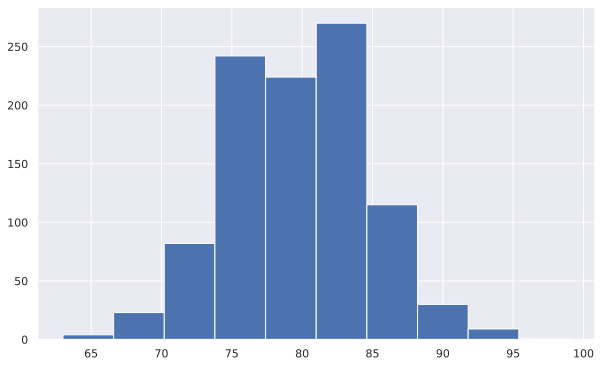

In [6]:
plt.hist(gen_pop)

Стандартизированная оценка (z-оценка, англ. standard score, z-score) — это мера относительного разброса наблюдаемого или измеренного значения, которая показывает, сколько стандартных отклонений составляет его разброс относительного среднего значения. Это безразмерный статистический показатель, используемый для сравнения значений разной размерности или шкалой измерений.

In [7]:
sample = np.array([89,99,93,84,79,61,82,81,87,82])
sample.mean()

#z = 10**0.5*(sample.mean()-80)/5

z = np.sqrt(len(sample)) * (sample.mean() - gen_pop.mean()) / gen_pop.std()


print(f'значение z-статистики',z)
print(f'среднее значение мини-выборки', sample.mean())
print(f'среднее значение всей выборки', gen_pop.mean())

значение z-статистики 2.647172892588856
среднее значение мини-выборки 83.7
среднее значение всей выборки 79.586


In [8]:
# p-value calculate

p_value = 1 - (stats.norm.cdf(z) - stats.norm.cdf(-z))

print(p_value)

0.00811678431487195


Z-значение отстоит от 0 более чем на 2 сигмы, т.е. отклонение среднего балла 10 респондентов находится очень далеко от среднего бала генеральной совокупности, а вероятность того, что это отклонение произошло случайно, всего около 0.01.

 Другими словами, если взять 10 человек из совокупности людей, которые оценивают наше "старое" пиво как N(80, 5^{2}), то вероятность того, что эти 10 человек могут случайно дать среднюю оценку "новому" пиву равную 83.7 баллам составляет всего около 2%. Скорее всего, если мы проведем полномасштабный опрос, то увидим, что потребители не просто не заметят изменения качества пива, а даже отметят его небольшое улучшение. Круто.

In [9]:
sample.std(ddof=1)

np.float64(10.055954565441423)

Для того, чтобы учитывать поправку в методе std() пакета NumPy есть параметр ddof, который по умолчанию равен 0, но если мы применяем std() к небольшой выборке, то необходимо явно указать, что ddof=1.
Смещенная оценка!!

В конце концов, не является ли оценка стандартного отклонения генеральной совокупности значением отклонения выборки более разумным решением? Давайте выясним это! Для этого просто сравним то, как могут быть распределены две статистики: (напомню, что параметрами называют характеристики генеральной совокупности, а статистиками - характеристики выборок)

\begin{equation}
Z = \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}} \;
\end{equation}

\begin{equation}
T = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}}.
\end{equation}

По сути мы просто придумали новую T-статистику, которая отличается от Z-статистики только тем, что в знаменателе стоит не \sigma генеральной совокупности, а s выборки.


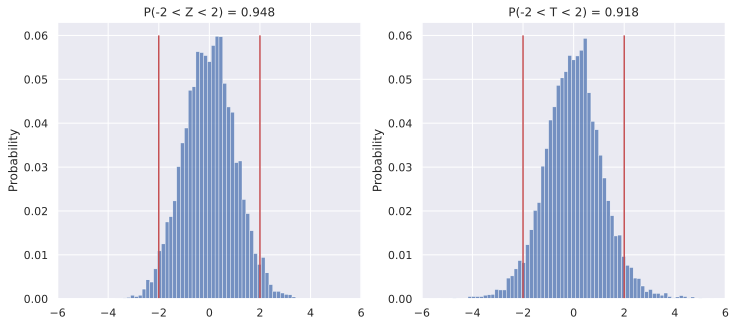

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize = (12, 5))

N = 10000
samples = stats.norm.rvs(80, 5, (N, 10))
statistics = [lambda x: 10**0.5*(np.mean(x, axis=1) - 80)/5,
              lambda x: 10**0.5*(np.mean(x, axis=1) - 80)/np.std(x, axis=1, ddof=1)]
title = 'ZT'
bins = np.linspace(-6, 6, 80, endpoint=True)

for i in range(2):
    values = statistics[i](samples)
    sns.histplot(x=values ,stat='probability', bins=bins, ax=ax[i])
    p = values[(values > -2)&(values < 2)].size/N
    ax[i].set_title('P(-2 < {} < 2) = {:.3}'.format(title[i], p))
    ax[i].set_xlim(-6, 6)
    ax[i].vlines([-2, 2], 0, 0.06, color='r');

Просто мне кажется, что так можно продемонстрировать, как едва заметные черты могут оказаться чрезвычайно важными для исследователя. На что я хочу обратить ваше внимание? Во-первых, и слева, и справа мы видим свиду два одинаковых колоколообразных распределения. Вполне уместно предположить, что это два стандартных нормальных распределения, верно? Но, вот что любопытно, в N(0, 1)интервал [-2\sigma; 2\sigma]должен содержать около 95.5% всех значений. Для Z-статистики это требование выполняется, а для придуманной нами T-статистики не очень, потому что только 92-93% ее значений укладываются в заданный интервал. Казалось бы, что отличие не столь велико, чтобы заподозрить какую-то закономерность,

Вам не кажется, что у распределения T-статистик основание чуть шире? Это хорошо видно по выпирающим за красные линии, так называемым - хвостам. А то, что эти хвосты несколько больше, или как еще говорят - тяжелее, чем у нормального распределения, так же будет означать, что мы будем наблюдать несколько больше сильных отклонений от вершины распределения. Проще говоря, мы теперь можем учитывать дисперсию выборки при оценке параметров генеральной совокупности. Однако, мы так и не ответили на вопрос - хорошо ли, можно ли, да и вообще зачем оценивать \sigmaгенеральной совокупности значением стандартного отклонения sвыборки.

# stohastic system

In [11]:
!pip install control --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 9.8 MB/s eta 0:00:00


In [12]:
import control
import matplotlib.pyplot as plt
import numpy as np

In [13]:
K = 0.1
T = 2
zeta = 0.1
num = np.array([K])
den = np.array([T**2, 2*T*zeta, 1])
W1 = control.tf(num, den)
W2 = control.tf([1],[0, 1])
Wfeedback = control.feedback(W1, W2, sign = -1)
print('W_замкнутая(s) = ', Wfeedback)

W_замкнутая(s) =  <TransferFunction>: sys[2]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

          0.1
  -------------------
  4 s^2 + 0.4 s + 1.1


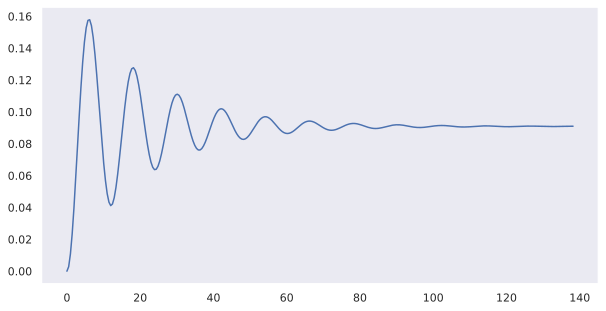

In [14]:
#реакция на ступенчатое воздействие при К = 1
t, y = control.step_response(Wfeedback)
plt.figure(figsize=(10,5))
plt.plot(t, y)
plt.grid()
plt.show()

In [15]:
sysABCD = control.tf2ss(Wfeedback)
print(sysABCD.A)
print(sysABCD.B)
print(sysABCD.C)

[[-0.1   -0.275]
 [ 1.     0.   ]]
[[1.]
 [0.]]
[[0.    0.025]]


In [16]:
class ODESolver:
  def __init__(self, f):
    # Wrap user’s f in a new function that always
    # converts list/tuple to array (or let array be array)
    self.model = f
    self.f = lambda t, x: np.asarray(f(t, x), float)

  def set_initial_condition(self, x0):
    if np.isscalar(x0):
      self.neq = 1 # scalar ODE
      x0 = float(x0)
    else:
      x0 = np.asarray(x0)
      self.neq = x0.size
    self.x0 = x0

# Compute solution for t_span[0] <= t <= t_span[1], using N steps
  def solve(self, t_span, N):
    t0, T = t_span
    self.dt = (T - t0) / N
    self.t = np.zeros(N + 1) # N steps ~ N+1 time points
    if self.neq == 1:
      self.x = np.zeros(N + 1)
    else:
      self.x = np.zeros((N + 1, self.neq))

    msg = "Please set initial condition before calling solve"
    assert hasattr(self, "x0"), msg

    self.t[0] = t0
    self.x[0] = self.x0
    for n in range(N):
      self.n = n
      self.t[n + 1] = self.t[n] + self.dt
      self.x[n + 1] = self.advance()
    return self.t, self.x

  def advance(self):
    raise NotImplementedError("Advance method is not implemented in the base class")

In [17]:
class RungeKutta4(ODESolver):
  def advance(self):
    x, f, n, t = self.x, self.f, self.n, self.t
    dt = self.dt
    dt2 = dt / 2.0
    k1 = f(t[n], x[n], )
    k2 = f(t[n] + dt2, x[n] + dt2 * k1, )
    k3 = f(t[n] + dt2, x[n] + dt2 * k2, )
    k4 = f(t[n] + dt, x[n] + dt * k3, )
    return x[n] + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

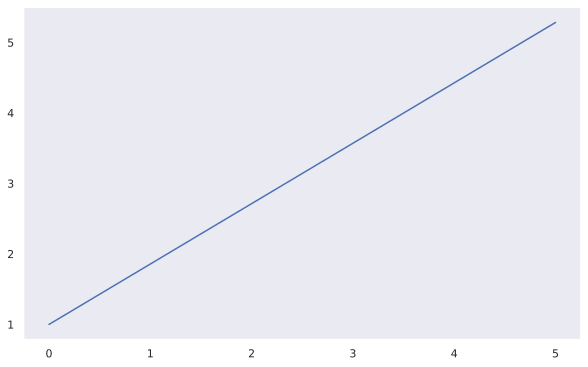

In [18]:
def f(t, x):
  return x + np.cos(t)
t_span = (0, 5)
N = 25

rk4 = RungeKutta4(f)
rk4.set_initial_condition(x0 = 3)
t_solve, x_solve = rk4.solve(t_span, N)
#plt.plot(t3, u3, label="Runge-Kutta 4")
plt.plot(t_span, f(t_span, t_span))
plt.grid()

In [19]:
class ABCDt:
  def __init__(self,mu,u,A,B):
    self.mu = mu
    self.u = u
    self.A = A
    self.B = B
  def __call__(self,t,x):
    time_delta = 1 - 0.5*np.sin(2*np.pi/4*t)
    dx1 = self.A[0,0] * x[0] * time_delta + self.A[0,1] * x[1] * time_delta + self.B[0,0]*self.u
    dx2 = self.A[1,0] * x[0] * time_delta + self.A[1,1] * x[1] * time_delta + self.B[1,0]*self.u
    return dx1,dx2

In [20]:
class ABCD:
  def __init__(self,mu,u,A,B):
    self.mu = mu
    self.u = u
    self.A = A
    self.B = B
  def __call__(self,t,x):
    dx1 = self.A[0,0] * x[0] + self.A[0,1] * x[1] + self.B[0,0]*self.u
    dx2 = self.A[1,0] * x[0] + self.A[1,1] * x[1] + self.B[1,0]*self.u
    return dx1, dx2

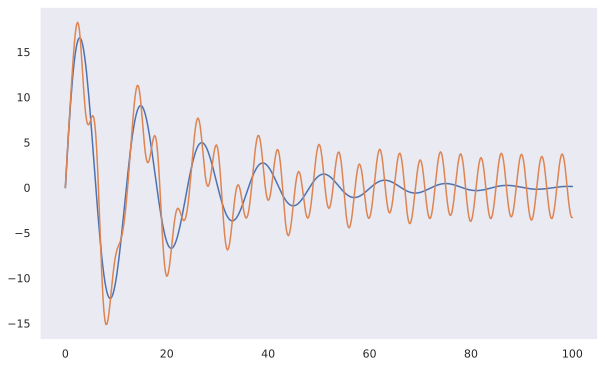

In [21]:
u = 10
model = ABCD(mu=1 , u=u, A=sysABCD.A, B=sysABCD.B)
solver = RungeKutta4(model)
solver.set_initial_condition([0, 0])

model_t = ABCDt(mu = 1, u=u, A=sysABCD.A, B=sysABCD.B)
solver_t = RungeKutta4(model_t)
solver_t.set_initial_condition([0, 0])

t  , x = solver.solve(t_span=(0,100),N=500)
t_t, x_t = solver_t.solve(t_span=(0,100),N=500)

plt.plot(t,x[:,0], t_t, x_t[:,0])
plt.grid()
plt.show()

# Non-statonary timeseries

In [28]:
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from pandas import read_csv

!pip install colorednoise --quiet
import colorednoise as cn

**Stationary Process:** A process that generates a stationary series of observations.

**Stationary Model:** A model that describes a stationary series of observations.

**Trend Stationary:** A time series that does not exhibit a trend.

**Seasonal Stationary:** A time series that does not exhibit seasonality.

**Strictly Stationary:** A mathematical definition of a stationary process, specifically that the joint distribution of observations is invariant to time shift.

White (beta=0): Equal energy per frequency. Sounds like static.

Pink (beta=1): Equal energy per octave (1/f). Sounds deeper, like rain.

Brownian (beta=2): Energy drops off quickly (1/f^2). Sounds like a low rumble.

Violet noise (beta=-2) Rapid, jittery fluctuations; values "bounce" oppositely (anti-persistent)



In [75]:
# Parameters for noise generation
samples = 2**10  # Number of samples (power of 2 for FFT efficiency)

# Generate White noise
# beta = 0 for white noise
white_noise = cn.powerlaw_psd_gaussian(0, samples)

# Generate 1/f (Pink) noise
# beta = 1 for pink noise
pink_noise = cn.powerlaw_psd_gaussian(1, samples)

# Generate 1/f^2 (Brownian) noise
# beta = 2 for brownian noise
brownian_noise = cn.powerlaw_psd_gaussian(2, samples)

# Generate Anti-persistent noise
# beta = -2 for anti-persistent noise (violet noise)
anti_persistent_noise = cn.powerlaw_psd_gaussian(-2, samples)

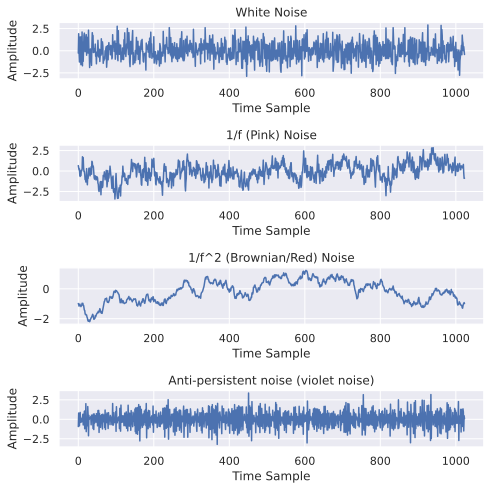

Generated White noise, 1/f (Pink) noise, and 1/f^2 (Brownian/Red) noise.
White noise has a flat power spectral density.
Pink noise has a power spectral density proportional to 1/f.
Brownian noise (also known as red noise) has a power spectral density proportional to 1/f^2.


In [76]:
# Plotting the signals
plt.figure(figsize=(7, 7))

plt.subplot(4, 1, 1)
plt.plot(white_noise)
plt.title('White Noise')
plt.xlabel('Time Sample')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(pink_noise)
plt.title('1/f (Pink) Noise')
plt.xlabel('Time Sample')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(brownian_noise)
plt.title('1/f^2 (Brownian/Red) Noise')
plt.xlabel('Time Sample')
plt.ylabel('Amplitude')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(anti_persistent_noise)
plt.title('Anti-persistent noise (violet noise)')
plt.xlabel('Time Sample')
plt.ylabel('Amplitude')
plt.grid(True)

plt.tight_layout()
plt.show()

print('Generated White noise, 1/f (Pink) noise, and 1/f^2 (Brownian/Red) noise.')
print('White noise has a flat power spectral density.')
print('Pink noise has a power spectral density proportional to 1/f.')
print('Brownian noise (also known as red noise) has a power spectral density proportional to 1/f^2.')

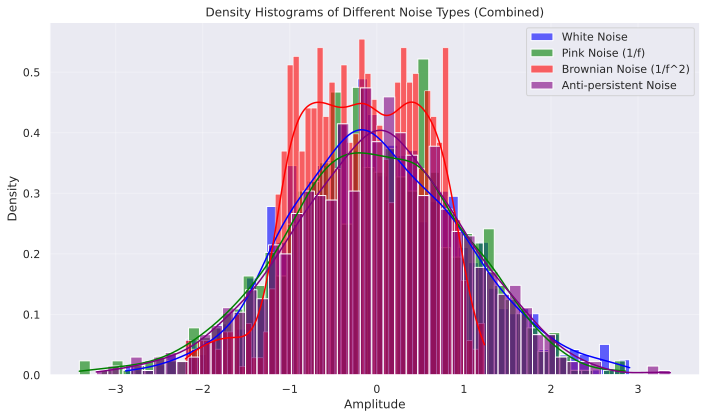

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

noise_signals_to_plot = {
    'White Noise': white_noise,
    'Pink Noise (1/f)': pink_noise,
    'Brownian Noise (1/f^2)': brownian_noise,
    'Anti-persistent Noise': anti_persistent_noise
}

plt.figure(figsize=(10, 6))

# Define a color palette for the histograms
colors = ['blue', 'green', 'red', 'purple']

i = 0
for name, signal in noise_signals_to_plot.items():
    sns.histplot(signal, bins=50, kde=True, stat='density', color=colors[i], label=name, alpha=0.6)
    i += 1

plt.title('Density Histograms of Different Noise Types (Combined)')
plt.xlabel('Amplitude')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
import numpy as np

def calculate_hurst_rs(series):
    """
    Calculates the Hurst exponent using the Rescaled Range (R/S) method.

    Args:
        series (np.ndarray): The time series data.

    Returns:
        tuple: (Hurst exponent H, Intercept C, log_lag values, log_rs values)
               or (np.nan, np.nan, np.array([]), np.array([])) if calculation fails.
    """
    # Ensure series is valid and has enough data points
    if len(series) < 10 or np.all(np.isnan(series)):
        return np.nan, np.nan, np.array([]), np.array([])

    # Remove NaNs if any remaining after initial check, as R/S requires continuous data
    series = series[~np.isnan(series)]
    if len(series) < 10: # Re-check length after dropping NaNs
        return np.nan, np.nan, np.array([]), np.array([])

    L = len(series)
    if L < 2: # Need at least 2 data points for meaningful calculation
        return np.nan, np.nan, np.array([]), np.array([])

    max_lag = int(L / 2)
    if max_lag < 2: # Ensure there are enough lags to work with
        return np.nan, np.nan, np.array([]), np.array([])

    lags = range(2, max_lag + 1)
    rs_values_for_fit = [] # Store (log(lag), log(avg_rs)) pairs

    try:
        for lag in lags:
            segment_rs_values = [] # Initialize for each lag
            num_segments = L // lag
            if num_segments == 0: continue

            for i in range(num_segments):
                segment = series[i * lag : (i + 1) * lag]

                # Calculate the mean of the segment
                mean_segment = np.mean(segment)

                # Create a mean-adjusted series
                y = segment - mean_segment

                # Calculate the cumulative sum (random walk)
                z = np.cumsum(y)

                # Calculate the range (max - min)
                R = np.max(z) - np.min(z)

                # Calculate the standard deviation
                S = np.std(segment)

                if S == 0: # Avoid division by zero
                    segment_rs_values.append(np.nan)
                else:
                    segment_rs_values.append(R / S)

            # Average R/S over all segments for this lag
            avg_rs = np.nanmean(segment_rs_values)
            if not np.isnan(avg_rs) and avg_rs > 0: # Ensure avg_rs is positive for log
                rs_values_for_fit.append((np.log(lag), np.log(avg_rs)))

        if len(rs_values_for_fit) < 2: # Need at least two points to fit a line
            return np.nan, np.nan, np.array([]), np.array([])

        # Fit a linear regression to log(R/S) vs log(lag)
        log_lag_for_plot = np.array([x[0] for x in rs_values_for_fit])
        log_rs_for_plot = np.array([x[1] for x in rs_values_for_fit])

        H, C = np.polyfit(log_lag_for_plot, log_rs_for_plot, 1)
        return H, C, log_lag_for_plot, log_rs_for_plot

    except Exception as e:
        # Catch any other potential errors during calculation
        return np.nan, np.nan, np.array([]), np.array([])

print("Function `calculate_hurst_rs` defined.")

Function `calculate_hurst_rs` defined.


In [79]:
hurst_white_noise_tuple = calculate_hurst_rs(white_noise)
hurst_white_noise = hurst_white_noise_tuple[0]
hurst_pink_noise_tuple = calculate_hurst_rs(pink_noise)
hurst_pink_noise = hurst_pink_noise_tuple[0]
hurst_brownian_noise_tuple = calculate_hurst_rs(brownian_noise)
hurst_brownian_noise = hurst_brownian_noise_tuple[0]
hurst_anti_persis_noise_tuple = calculate_hurst_rs(anti_persistent_noise)
hurst_anti_persis_noise = hurst_anti_persis_noise_tuple[0]

print(f"Hurst Exponent for White Noise: {hurst_white_noise:.3f}")
print(f"Hurst Exponent for Pink Noise (1/f): {hurst_pink_noise:.3f}")
print(f"Hurst Exponent for Brownian Noise (1/f^2): {hurst_brownian_noise:.3f}")
print(f"Hurst Exponent for Violet Noise: {hurst_anti_persis_noise:.3f}")

print("\nInterpretation of Hurst Exponent (H):")
print("- H ≈ 0.5: Random walk (no long-term memory). This is characteristic of white noise.")
print("- H > 0.5: Persistent behavior (long-term positive autocorrelation). Past increases are likely to be followed by increases, and past decreases by decreases. Pink noise typically has H close to 1.")
print("- H < 0.5: Anti-persistent behavior (long-term negative autocorrelation). Past increases are likely to be followed by decreases, and vice versa.")

Hurst Exponent for White Noise: 0.545
Hurst Exponent for Pink Noise (1/f): 0.810
Hurst Exponent for Brownian Noise (1/f^2): 0.973
Hurst Exponent for Violet Noise: 0.142

Interpretation of Hurst Exponent (H):
- H ≈ 0.5: Random walk (no long-term memory). This is characteristic of white noise.
- H > 0.5: Persistent behavior (long-term positive autocorrelation). Past increases are likely to be followed by increases, and past decreases by decreases. Pink noise typically has H close to 1.
- H < 0.5: Anti-persistent behavior (long-term negative autocorrelation). Past increases are likely to be followed by decreases, and vice versa.


In [80]:
!pip install MFDFA --quiet
from MFDFA import MFDFA
import matplotlib.pyplot as plt
import numpy as np


--- Analyzing White Noise ---


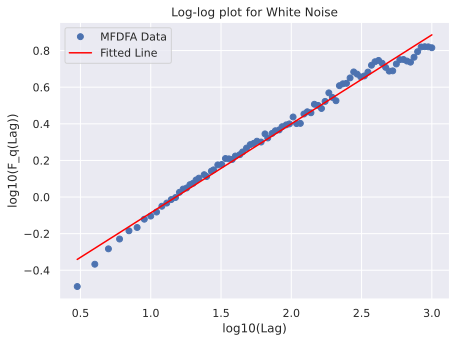

Estimated H for White Noise = 0.486

--- Analyzing Pink Noise (1/f) ---


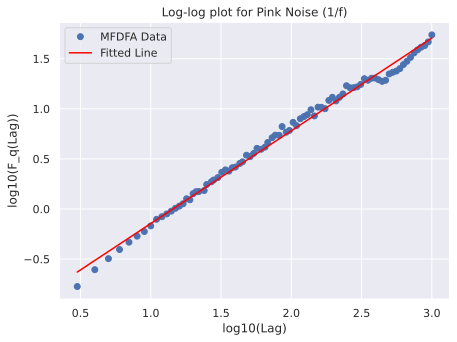

Estimated H for Pink Noise (1/f) = 0.926

--- Analyzing Brownian Noise (1/f^2) ---


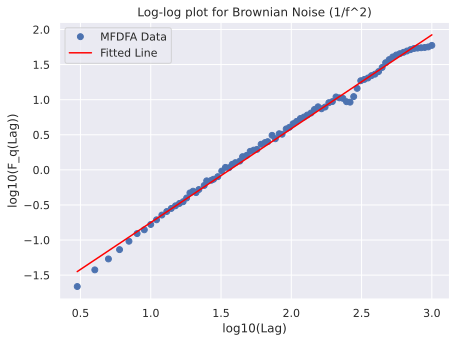

Estimated H for Brownian Noise (1/f^2) = 1.337

--- Analyzing Anti-persistent noise ---


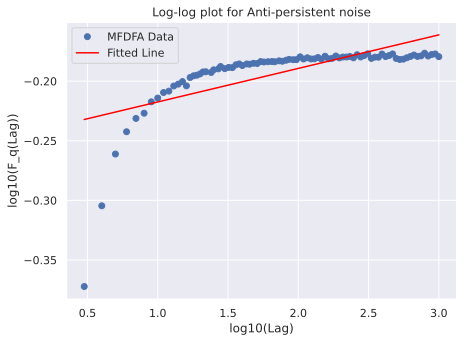

Estimated H for Anti-persistent noise = 0.028


In [81]:
noise_signals = {
    'White Noise': white_noise,
    'Pink Noise (1/f)': pink_noise,
    'Brownian Noise (1/f^2)': brownian_noise,
    'Anti-persistent noise' : anti_persistent_noise
}

# Select a band of lags
lag = np.unique(np.logspace(0.5, 3, 100, dtype=int))

# Select the power q
q = 2

# The order of the polynomial fitting
order = 1

for name, yy in noise_signals.items():
    print(f"\n--- Analyzing {name} ---")

    # Using the MFDFA library, the input is the signal itself
    # The function returns q-order Hurst exponents (Hq) but for a single q, it's just H
    # The function expects a time series (yy), not a profile.
    # The documentation for MFDFA suggests passing the series directly.
    lag_out, dfa_values = MFDFA(yy, lag=lag, q=q, order=order)

    # To uncover the Hurst index, lets get some log-log plots

    # And now we need to fit the line to find the slope
    # in a double logarithmic scales, i.e., you need to
    # fit the logs of the results

    # Ensure dfa_values is 1D for easier filtering
    dfa_values_flat = dfa_values.flatten()

    # Filter out NaNs and non-positive values from the flattened array
    valid_indices = ~np.isnan(dfa_values_flat) & (dfa_values_flat > 0)

    if np.sum(valid_indices) < 2:
        print("Not enough valid data points for fitting after filtering.")
        continue

    log_lag = np.log10(lag_out[valid_indices])
    log_dfa = np.log10(dfa_values_flat[valid_indices])

    # Fit the line.
    H_hat, C_hat = np.polyfit(log_lag, log_dfa, 1)

    plt.figure(figsize=(7, 5))
    plt.plot(log_lag, log_dfa, "o", label='MFDFA Data')
    # Extend the fitted line over the range of the log_lag data
    tlin = np.linspace(log_lag.min(), log_lag.max(), num=100)
    plt.plot(tlin, H_hat * tlin + C_hat, color='red', label='Fitted Line')
    plt.title(f'Log-log plot for {name}')
    plt.xlabel("log10(Lag)")
    plt.ylabel("log10(F_q(Lag))")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f'Estimated H for {name} = ' + '{:.3f}'.format(H_hat))


/tmp/ipykernel_235/508372458.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Noise Type', y='Hurst Exponent', data=hurst_df, palette='viridis')


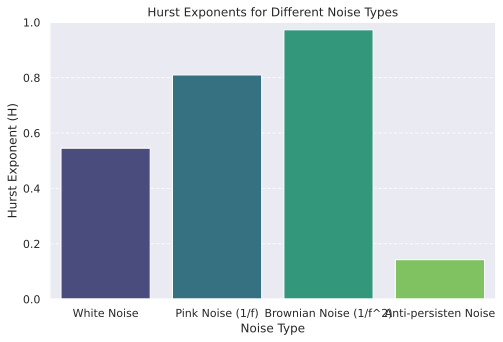

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for plotting the Hurst exponents
hurst_data = {
    'Noise Type': ['White Noise', 'Pink Noise (1/f)', 'Brownian Noise (1/f^2)', 'Anti-persisten Noise'],
    'Hurst Exponent': [hurst_white_noise, hurst_pink_noise, hurst_brownian_noise, hurst_anti_persis_noise]
}
hurst_df = pd.DataFrame(hurst_data)

# Plot the Hurst Exponents
plt.figure(figsize=(8, 5))
sns.barplot(x='Noise Type', y='Hurst Exponent', data=hurst_df, palette='viridis')
plt.ylim(0, 1) # Hurst exponent is typically between 0 and 1
plt.title('Hurst Exponents for Different Noise Types')
plt.xlabel('Noise Type')
plt.ylabel('Hurst Exponent (H)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



--- Analyzing White Noise using R/S method ---


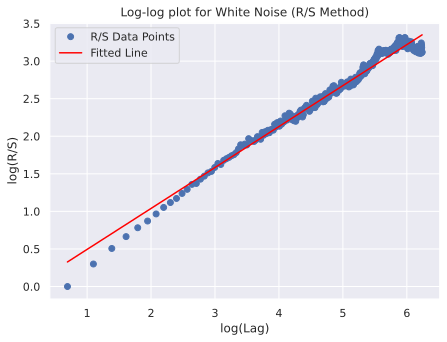

Estimated Hurst Exponent (H) for White Noise = 0.545

--- Analyzing Pink Noise (1/f) using R/S method ---


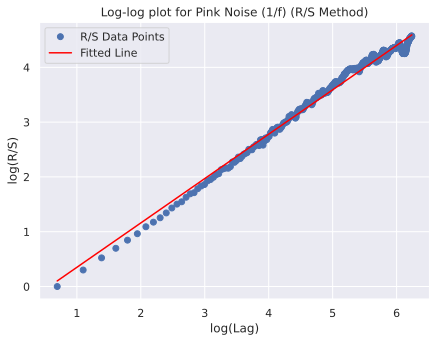

Estimated Hurst Exponent (H) for Pink Noise (1/f) = 0.810

--- Analyzing Brownian Noise (1/f^2) using R/S method ---


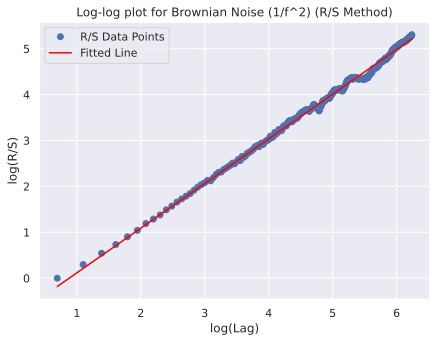

Estimated Hurst Exponent (H) for Brownian Noise (1/f^2) = 0.973

--- Analyzing Anti-persistent Noise using R/S method ---


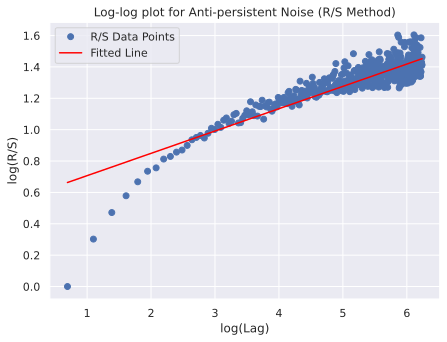

Estimated Hurst Exponent (H) for Anti-persistent Noise = 0.142


In [83]:
noise_signals = {
    'White Noise': white_noise,
    'Pink Noise (1/f)': pink_noise,
    'Brownian Noise (1/f^2)': brownian_noise,
    'Anti-persistent Noise': anti_persistent_noise
}

for name, yy in noise_signals.items():
    print(f"\n--- Analyzing {name} using R/S method ---")

    # Call the modified calculate_hurst_rs function
    H_hat, C_hat, log_lag, log_rs = calculate_hurst_rs(yy)

    if np.isnan(H_hat) or len(log_lag) < 2:
        print(f"Could not calculate Hurst exponent or perform fit for {name}. Skipping plotting.")
        continue

    plt.figure(figsize=(7, 5))
    plt.plot(log_lag, log_rs, "o", label='R/S Data Points')
    # Extend the fitted line over the range of the log_lag data
    tlin = np.linspace(log_lag.min(), log_lag.max(), num=100)
    plt.plot(tlin, H_hat * tlin + C_hat, color='red', label='Fitted Line')
    plt.title(f'Log-log plot for {name} (R/S Method)')
    plt.xlabel("log(Lag)")
    plt.ylabel("log(R/S)")
    plt.grid(True)
    plt.legend()
    plt.show()

    print(f'Estimated Hurst Exponent (H) for {name} = ' + '{:.3f}'.format(H_hat))


--- Analyzing White Noise using R/S method ---

--- Analyzing Pink Noise (1/f) using R/S method ---

--- Analyzing Brownian Noise (1/f^2) using R/S method ---

--- Analyzing Anti-persistent Noise using R/S method ---


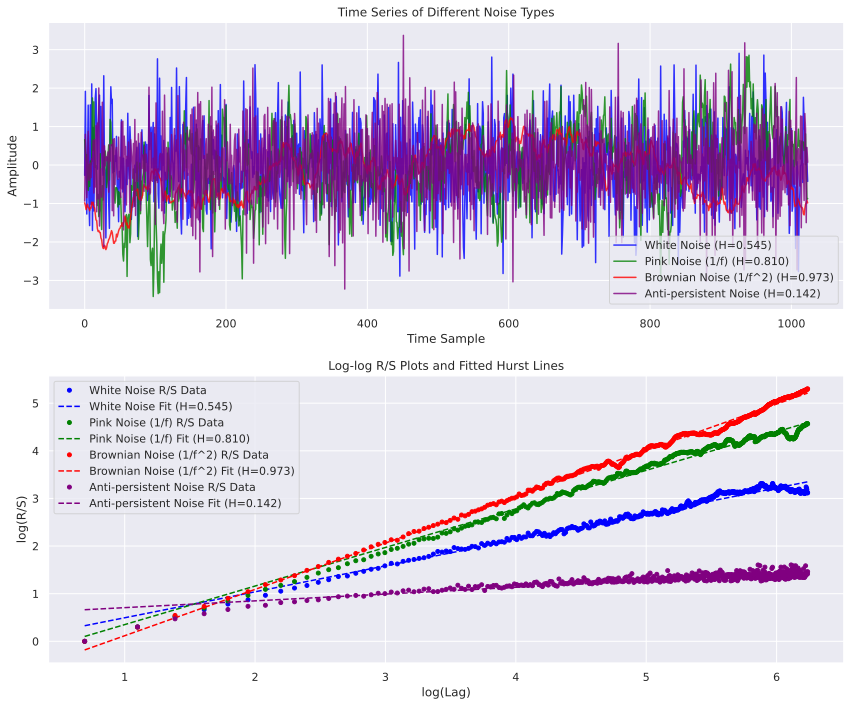


--- Summary of Estimated Hurst Exponents ---
Estimated Hurst Exponent (H) for White Noise = 0.545
Estimated Hurst Exponent (H) for Pink Noise (1/f) = 0.810
Estimated Hurst Exponent (H) for Brownian Noise (1/f^2) = 0.973
Estimated Hurst Exponent (H) for Anti-persistent Noise = 0.142


In [84]:
noise_signals = {
    'White Noise': white_noise,
    'Pink Noise (1/f)': pink_noise,
    'Brownian Noise (1/f^2)': brownian_noise,
    'Anti-persistent Noise': anti_persistent_noise
}

# Define a color map for different noise types
colors = {'White Noise': 'blue', 'Pink Noise (1/f)': 'green', 'Brownian Noise (1/f^2)': 'red', 'Anti-persistent Noise': 'purple'}

# Create a figure with two subplots: one for time series, one for R/S plots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Lists to store Hurst exponents for printing later
estimated_hurst_exponents = {}

for name, yy in noise_signals.items():
    print(f"\n--- Analyzing {name} using R/S method ---")

    # Call the modified calculate_hurst_rs function
    H_hat, C_hat, log_lag, log_rs = calculate_hurst_rs(yy)

    if np.isnan(H_hat) or len(log_lag) < 2:
        print(f"Could not calculate Hurst exponent or perform fit for {name}. Skipping plotting for this signal.")
        continue

    estimated_hurst_exponents[name] = H_hat

    # Subplot 1: Original Noise Signal
    axes[0].plot(yy, label=f'{name} (H={H_hat:.3f})', color=colors[name], alpha=0.8)

    # Subplot 2: Log-log plot for R/S Method and Fitted Line
    axes[1].plot(log_lag, log_rs, "o", label=f'{name} R/S Data', color=colors[name], markersize=4)
    tlin = np.linspace(log_lag.min(), log_lag.max(), num=100)
    axes[1].plot(tlin, H_hat * tlin + C_hat, color=colors[name], linestyle='--', label=f'{name} Fit (H={H_hat:.3f})')

# Set titles, labels, and legends for the first subplot (Time Series)
axes[0].set_title('Time Series of Different Noise Types')
axes[0].set_xlabel('Time Sample')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)
axes[0].legend()

# Set titles, labels, and legends for the second subplot (Log-log R/S Plots)
axes[1].set_title('Log-log R/S Plots and Fitted Hurst Lines')
axes[1].set_xlabel("log(Lag)")
axes[1].set_ylabel("log(R/S)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print all estimated Hurst exponents
print("\n--- Summary of Estimated Hurst Exponents ---")
for name, H in estimated_hurst_exponents.items():
    print(f'Estimated Hurst Exponent (H) for {name} = ' + '{:.3f}'.format(H))

# Spectral views

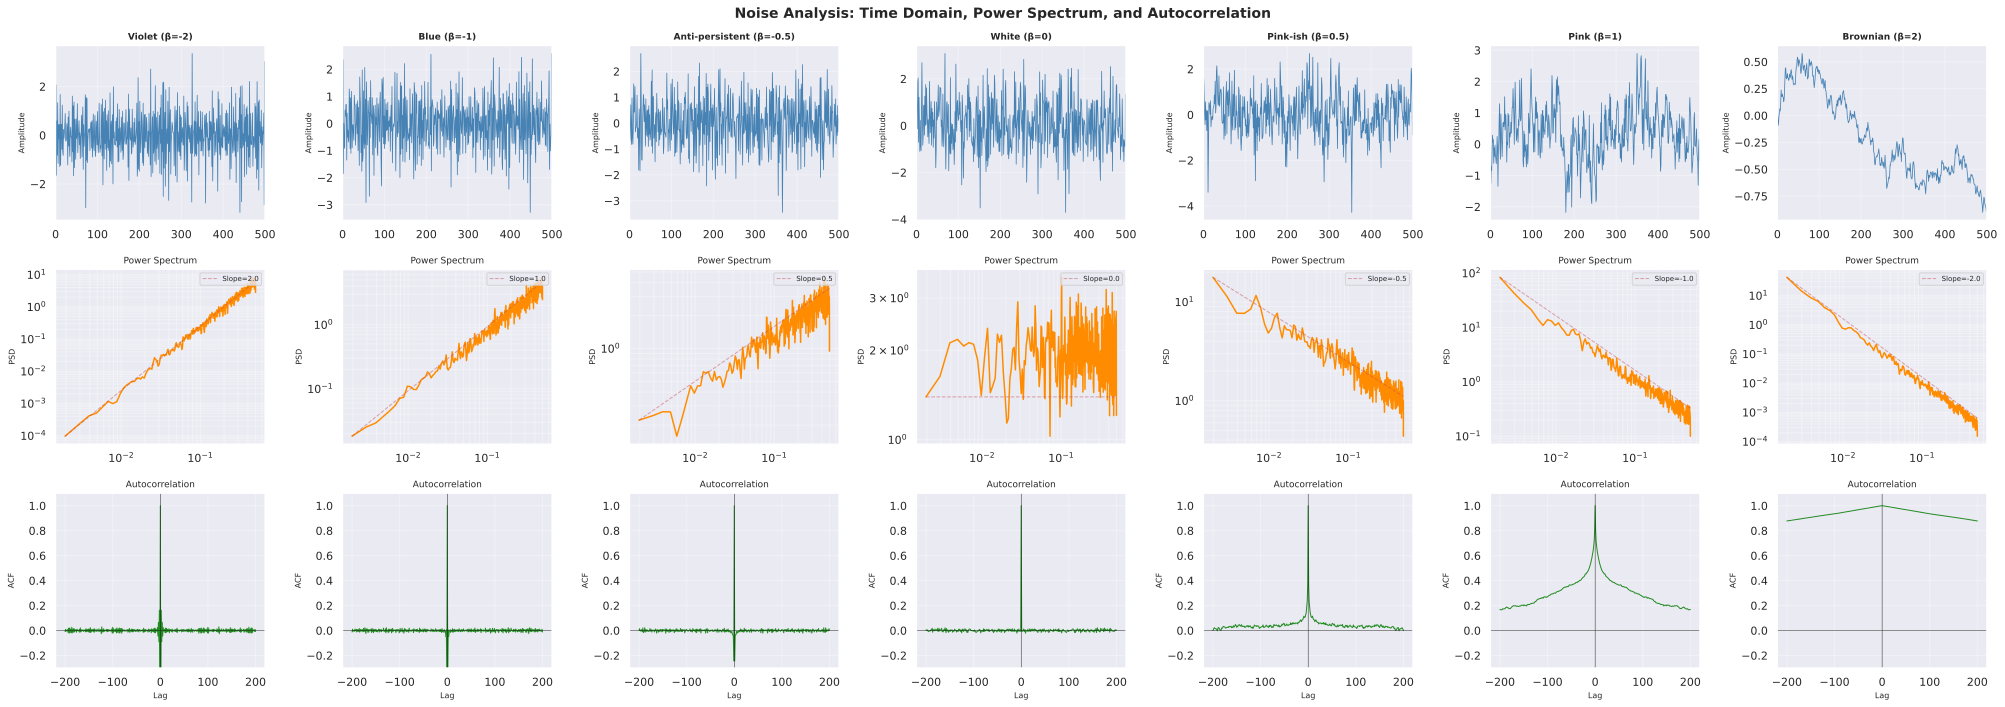

DETAILED ANALYSIS: Anti-Persistent Noise (β=-0.5)

📊 Theoretical Parameters:
   Beta (β): -0.5
   Hurst Exponent (H): 0.250
   Interpretation: Anti-persistent
   (H < 0.5 means negative autocorrelation → mean-reverting)

📈 Power Spectrum Analysis:
   Measured slope: 0.494
   Expected slope: 0.500
   Error: 0.006

🔄 Autocorrelation Analysis:
   Lag-1 ACF: -0.2374
   Interpretation: Negative (anti-persistent)
   A rise is likely followed by: a fall

📋 Statistical Properties:
   Mean: -0.000149
   Std Dev: 1.0000
   Skewness: -0.0136
   Kurtosis: 3.0972 (Gaussian ≈ 3.0)


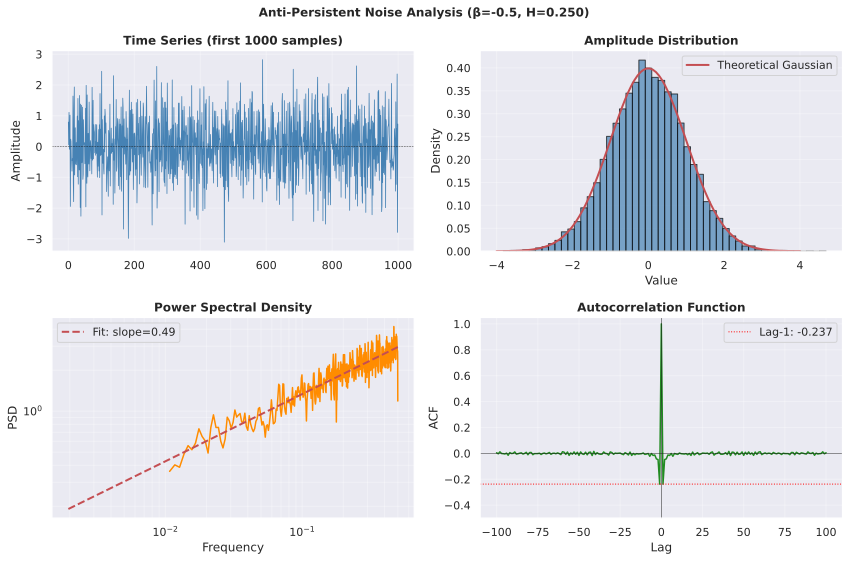


✅ Visualizations saved as:
   - noise_analysis_comparison.png (all noise types)
   - anti_persistent_detailed_analysis.png (β=-0.5 detailed)


In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import colorednoise as cn

# Generate different noise types
samples = 2**14  # 16384 samples for good frequency resolution
betas = [-2, -1, -0.5, 0, 0.5, 1, 2]  # violet, blue, anti-persistent, white, pinkish, pink, brownian
noise_colors = ['Violet (β=-2)', 'Blue (β=-1)', 'Anti-persistent (β=-0.5)',
                'White (β=0)', 'Pink-ish (β=0.5)', 'Pink (β=1)', 'Brownian (β=2)']

# Generate all noise signals
noises = [cn.powerlaw_psd_gaussian(beta, samples) for beta in betas]

# Normalize for visualization
noises = [n / np.std(n) for n in noises]

# Create figure with subplots
fig, axes = plt.subplots(3, len(betas), figsize=(4*len(betas), 10))
fig.suptitle('Noise Analysis: Time Domain, Power Spectrum, and Autocorrelation',
             fontsize=14, fontweight='bold')

# Time vector
t = np.arange(samples)

for idx, (beta, noise, name) in enumerate(zip(betas, noises, noise_colors)):

    # 1. TIME DOMAIN (top row)
    axes[0, idx].plot(t[:500], noise[:500], linewidth=0.8, color='steelblue')
    axes[0, idx].set_title(f'{name}', fontsize=9, fontweight='bold')
    axes[0, idx].set_ylabel('Amplitude', fontsize=8)
    axes[0, idx].grid(True, alpha=0.3)
    axes[0, idx].set_xlim(0, 500)

    # 2. POWER SPECTRAL DENSITY (middle row)
    freqs, psd = signal.welch(noise, fs=1.0, nperseg=1024, scaling='density')
    # Only plot positive frequencies (exclude DC)
    mask = freqs > 0.001
    axes[1, idx].loglog(freqs[mask], psd[mask], linewidth=1.5, color='darkorange')
    axes[1, idx].set_title('Power Spectrum', fontsize=9)
    axes[1, idx].set_ylabel('PSD', fontsize=8)
    axes[1, idx].grid(True, alpha=0.3, which='both')

    # Add theoretical slope line
    freqs_fit = freqs[mask][::10]  # subsample for clarity
    psd_fit = psd[mask][::10]
    slope = -beta  # PSD ∝ 1/f^β, so log(PSD) vs log(f) has slope -β
    axes[1, idx].loglog(freqs_fit, psd_fit[0]*(freqs_fit/freqs_fit[0])**slope,
                        'r--', alpha=0.5, linewidth=1, label=f'Slope={-beta:.1f}')
    axes[1, idx].legend(fontsize=7, loc='upper right')

    # 3. AUTOCORRELATION (bottom row)
    max_lag = 200
    autocorr = np.correlate(noise, noise, mode='full')
    autocorr = autocorr[len(autocorr)//2 - max_lag:len(autocorr)//2 + max_lag + 1]
    autocorr = autocorr / autocorr[max_lag]  # Normalize
    lags = np.arange(-max_lag, max_lag + 1)

    axes[2, idx].plot(lags, autocorr, linewidth=1, color='forestgreen')
    axes[2, idx].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[2, idx].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    axes[2, idx].set_title('Autocorrelation', fontsize=9)
    axes[2, idx].set_xlabel('Lag', fontsize=8)
    axes[2, idx].set_ylabel('ACF', fontsize=8)
    axes[2, idx].grid(True, alpha=0.3)
    axes[2, idx].set_ylim(-0.3, 1.1)

plt.tight_layout()
plt.savefig('noise_analysis_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# DETAILED ANALYSIS FOR YOUR ANTI-PERSISTENT NOISE (β=-0.5)
# ============================================================================

print("="*70)
print("DETAILED ANALYSIS: Anti-Persistent Noise (β=-0.5)")
print("="*70)

beta_target = -0.5
noise_anti = cn.powerlaw_psd_gaussian(beta_target, samples)
noise_anti = noise_anti / np.std(noise_anti)

# Calculate Hurst exponent estimate
# For power-law noise: H = (β + 1) / 2
H_estimated = (beta_target + 1) / 2
print(f"\n📊 Theoretical Parameters:")
print(f"   Beta (β): {beta_target}")
print(f"   Hurst Exponent (H): {H_estimated:.3f}")
print(f"   Interpretation: {'Anti-persistent' if H_estimated < 0.5 else 'Persistent' if H_estimated > 0.5 else 'Random walk'}")
print(f"   (H < 0.5 means negative autocorrelation → mean-reverting)")

# Power spectrum analysis
freqs, psd = signal.welch(noise_anti, fs=1.0, nperseg=1024, scaling='density')
mask = freqs > 0.01

# Fit slope in log-log space
log_freqs = np.log10(freqs[mask])
log_psd = np.log10(psd[mask])
slope_fit, intercept = np.polyfit(log_freqs, log_psd, 1)

print(f"\n📈 Power Spectrum Analysis:")
print(f"   Measured slope: {slope_fit:.3f}")
print(f"   Expected slope: {-beta_target:.3f}")
print(f"   Error: {abs(slope_fit - (-beta_target)):.3f}")

# Autocorrelation at lag 1
autocorr_full = np.correlate(noise_anti, noise_anti, mode='full')
autocorr_normalized = autocorr_full / autocorr_full[len(autocorr_full)//2]
lag1_acf = autocorr_normalized[len(autocorr_normalized)//2 + 1]

print(f"\n🔄 Autocorrelation Analysis:")
print(f"   Lag-1 ACF: {lag1_acf:.4f}")
print(f"   Interpretation: {'Negative (anti-persistent)' if lag1_acf < 0 else 'Positive (persistent)'}")
print(f"   A rise is likely followed by: {'a fall' if lag1_acf < 0 else 'another rise'}")

# Statistical properties
print(f"\n📋 Statistical Properties:")
print(f"   Mean: {np.mean(noise_anti):.6f}")
print(f"   Std Dev: {np.std(noise_anti):.4f}")
print(f"   Skewness: {np.mean(((noise_anti - np.mean(noise_anti)) / np.std(noise_anti))**3):.4f}")
print(f"   Kurtosis: {np.mean(((noise_anti - np.mean(noise_anti)) / np.std(noise_anti))**4):.4f} (Gaussian ≈ 3.0)")

# Create detailed plot for anti-persistent noise
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Anti-Persistent Noise Analysis (β={beta_target}, H={H_estimated:.3f})',
             fontsize=12, fontweight='bold')

# Time series (zoomed)
axes[0, 0].plot(t[:1000], noise_anti[:1000], linewidth=0.8, color='steelblue')
axes[0, 0].set_title('Time Series (first 1000 samples)', fontweight='bold')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

# Histogram
axes[0, 1].hist(noise_anti, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# Overlay Gaussian
x_gauss = np.linspace(-4, 4, 100)
y_gauss = 1/np.sqrt(2*np.pi) * np.exp(-x_gauss**2/2)
axes[0, 1].plot(x_gauss, y_gauss, 'r-', linewidth=2, label='Theoretical Gaussian')
axes[0, 1].set_title('Amplitude Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Power spectrum
axes[1, 0].loglog(freqs[mask], psd[mask], linewidth=1.5, color='darkorange')
axes[1, 0].loglog(freqs_fit, 10**intercept * (freqs_fit)**slope_fit,
                  'r--', linewidth=2, label=f'Fit: slope={slope_fit:.2f}')
axes[1, 0].set_title('Power Spectral Density', fontweight='bold')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_ylabel('PSD')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, which='both')

# Autocorrelation
max_lag = 100
autocorr = np.correlate(noise_anti, noise_anti, mode='full')
autocorr = autocorr[len(autocorr)//2 - max_lag:len(autocorr)//2 + max_lag + 1]
autocorr = autocorr / autocorr[max_lag]
lags = np.arange(-max_lag, max_lag + 1)

axes[1, 1].plot(lags, autocorr, linewidth=1.5, color='forestgreen')
axes[1, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[1, 1].axhline(y=lag1_acf, color='red', linestyle=':', linewidth=1, label=f'Lag-1: {lag1_acf:.3f}')
axes[1, 1].set_title('Autocorrelation Function', fontweight='bold')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('ACF')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(-0.5, 1.05)

plt.tight_layout()
plt.savefig('anti_persistent_detailed_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✅ Visualizations saved as:")
print("   - noise_analysis_comparison.png (all noise types)")
print("   - anti_persistent_detailed_analysis.png (β=-0.5 detailed)")
print("="*70)